In [2]:
import matplotlib.pyplot as plt, numpy as np
from astropy.io import fits

In [7]:
files = [
    "M13_0001.fits",
    "M13_0002.fits",
    "M13_0003.fits",
    "M13_0004.fits",
    "M13_0005.fits"
]

In [8]:
images = []

for f in files:
    with fits.open(f) as hdul:
        data = hdul[0].data
        images.append(data)


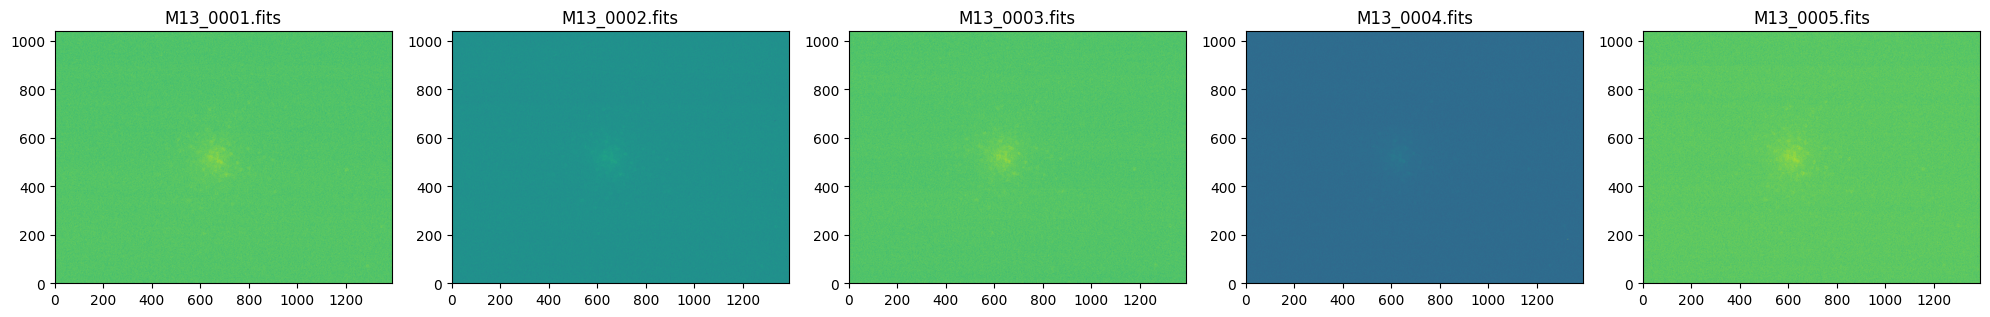

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, ax in enumerate(axes):
    ax.imshow(images[i], origin="lower")
    ax.set_title(files[i])

plt.tight_layout()
plt.show()


'\nthe matching color scale allows us to see which is brighter/noisier, and the stars are able to show up more uniformly. \nthe differences between exposures also become more visible\\'

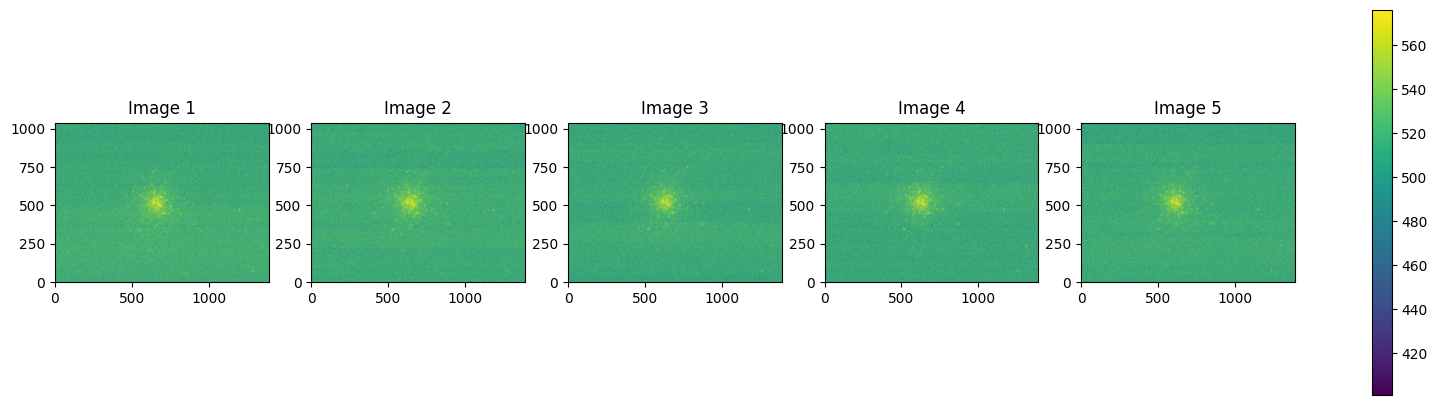

In [23]:
all_pixels = np.concatenate([img.ravel() for img in images])
vmin, vmax = np.percentile(all_pixels, [1, 99]) 

fig, ax = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    im = ax[i].imshow(images[i], origin="lower", vmin=vmin, vmax=vmax)
    ax[i].set_title(f"Image {i+1}")

plt.colorbar(im, ax=ax.ravel().tolist())


'''
the matching color scale allows us to see which is brighter/noisier, and the stars are able to show up more uniformly. 
the differences between exposures also become more visible\\\
'''


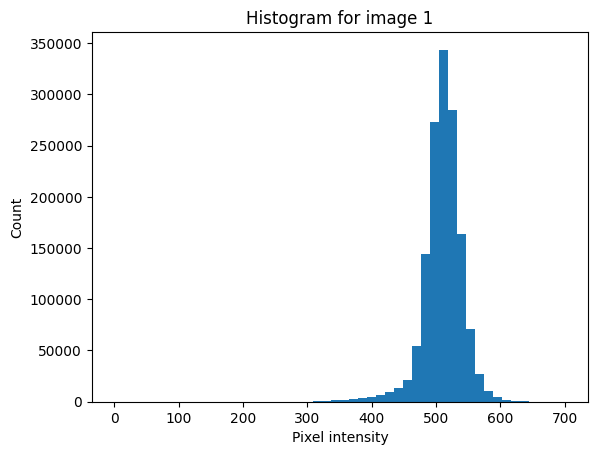

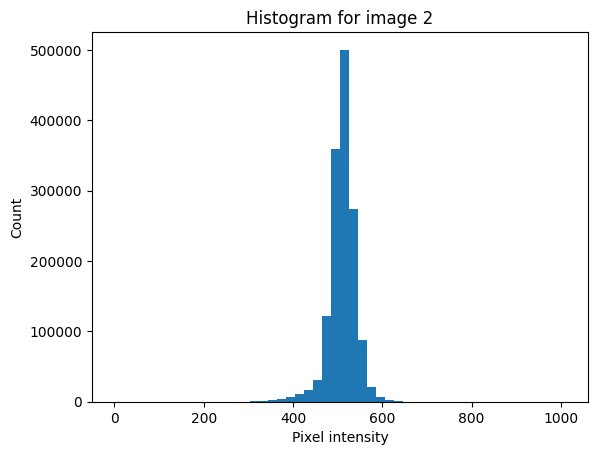

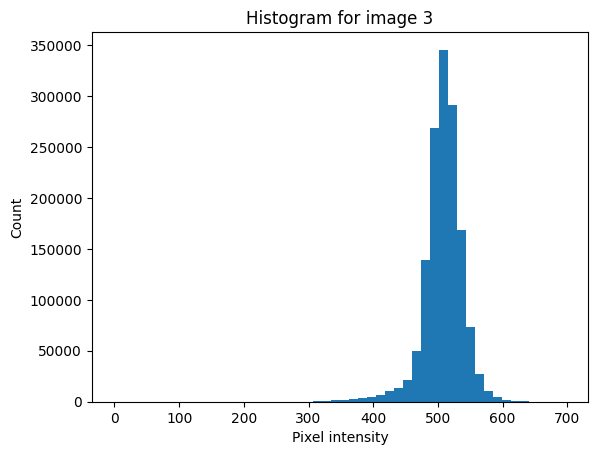

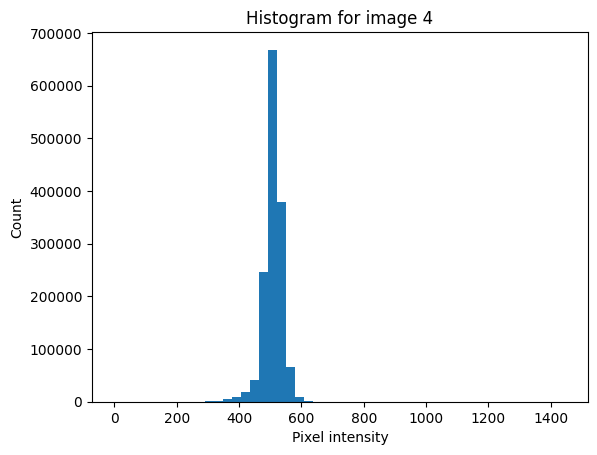

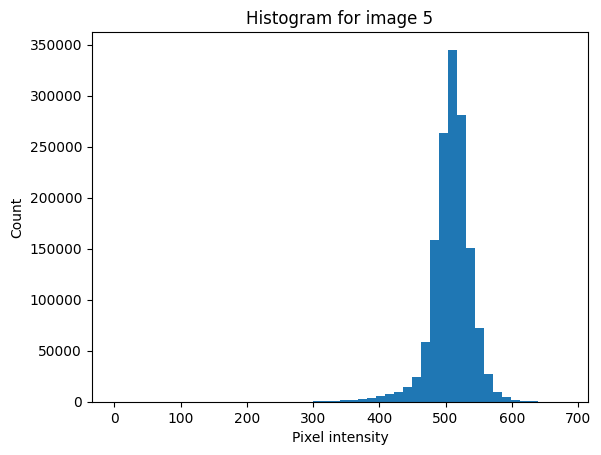

M13_0001.fits median = 512.0 mean = 510.4706668600796
M13_0002.fits median = 511.0 mean = 509.7460150033157
M13_0003.fits median = 510.0 mean = 508.0498729000884
M13_0004.fits median = 509.0 mean = 507.90583554376656
M13_0005.fits median = 510.0 mean = 508.7919920148099


In [25]:
for i, data in enumerate(images):
    plt.figure()
    plt.hist(data.ravel(), bins=50)
    plt.title(f"Histogram for image {i+1}")
    plt.xlabel("Pixel intensity")
    plt.ylabel("Count")
    plt.show()

'''
x axis = pixel intensity, y axis = number of pixels with that intensity
most intensities cluster around median
bin=50 means we divide the data range into 50 intervals
the spread is typically narrow
'''

for i, img in enumerate(images):
    print(files[i], 
          "median =", np.median(img),
          "mean =", np.mean(img))



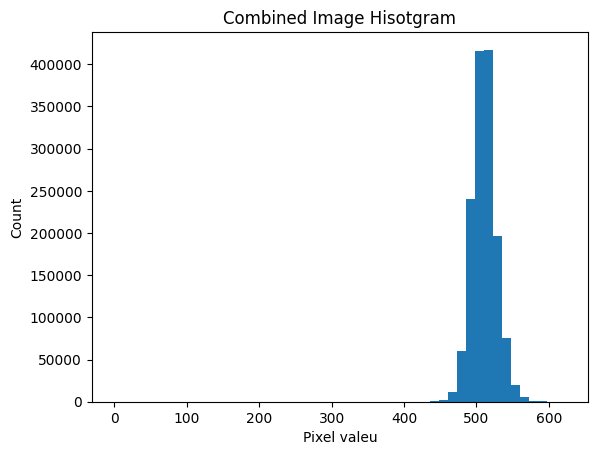

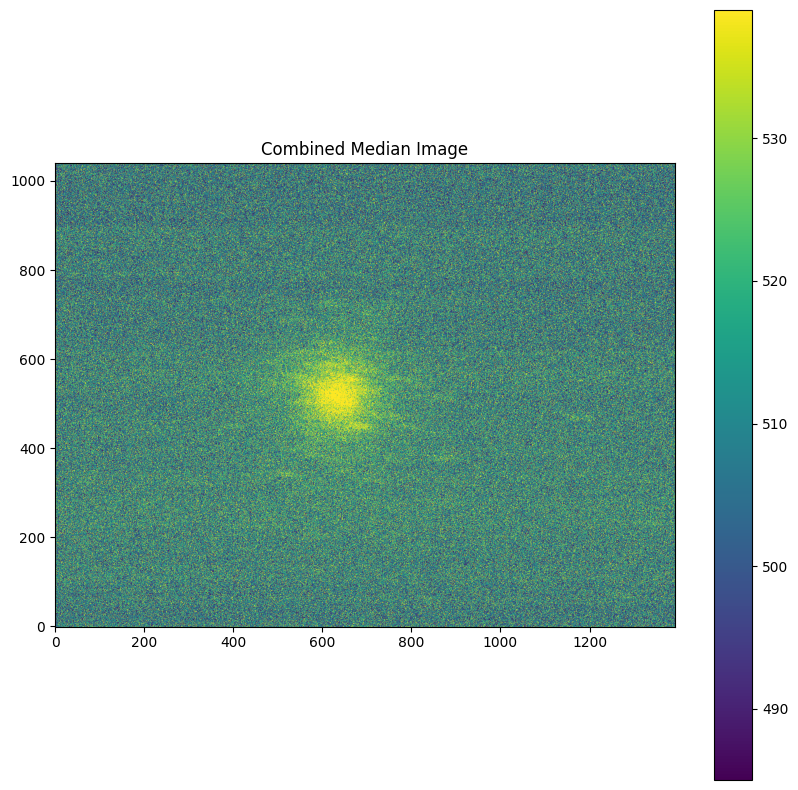

485.0 539.0 54.0


In [28]:
combined = np.median(np.array(images), axis=0)
np.median(combined)


plt.hist(combined.ravel(), bins=50)
plt.xlabel("Pixel valeu")
plt.ylabel("Count")
plt.title("Combined Image Hisotgram")
plt.show()

plt.figure(figsize=(10,10))
plt.imshow(combined, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title("Combined Median Image")
plt.show()

vmin = np.percentile(combined, 5)
vmax = np.percentile(combined, 95)

print(vmin, vmax, vmax - vmin) #the difference is significantly less than 100?

'''the combined image seems to be smoother/more detailed than the original which is a lot more grainy. 
the background is also more even (less of these lines)'''

fits.writeto("combined.fits", combined, overwrite=True)






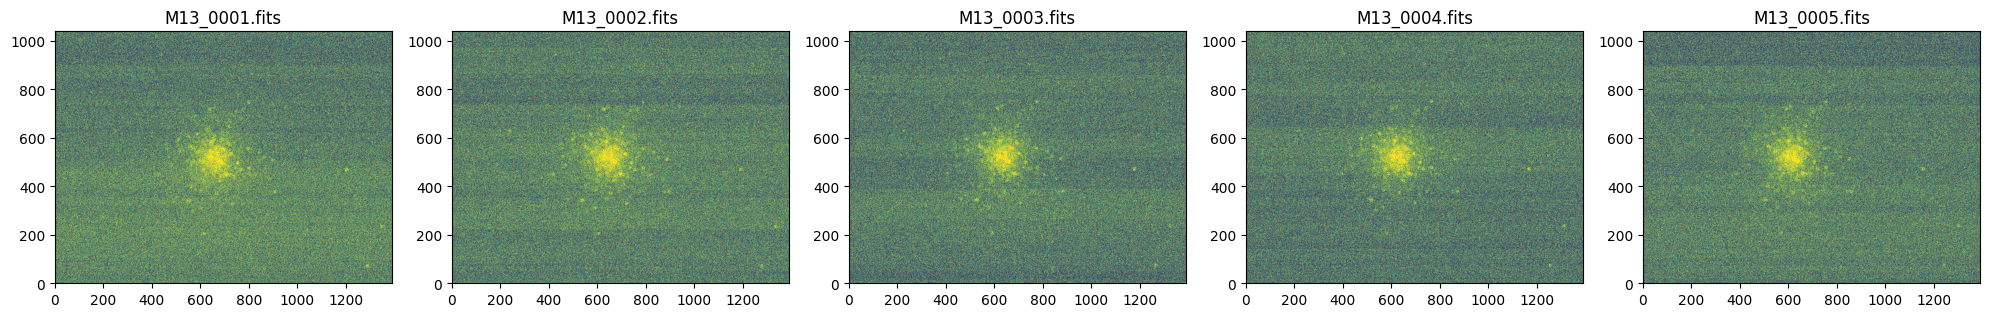